In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv(
    '/content/drive/MyDrive/GSE65391_series_matrix.txt.gz',
    sep='\t',
    comment='!',
    low_memory=False
)

print(df.shape)
df.head()

(43799, 997)


,ID_REF,GSM1594219,GSM1594220,GSM1594221,GSM1594222,GSM1594223,GSM1594224,GSM1594225,GSM1594226,GSM1594227,...,GSM1595213,GSM1595214,GSM1595215,GSM1595216,GSM1595217,GSM1595218,GSM1595219,GSM1595220,GSM1595221,GSM1595222
0,ILMN_1343291,13.780018,13.612146,14.042542,13.750733,13.469943,13.871745,13.732356,13.962190,14.202078,...,12.770966,13.772815,14.020652,13.678016,13.814081,13.732577,14.078057,13.867857,13.995211,13.515019
1,ILMN_1343295,11.081396,10.186098,10.340040,10.241601,10.878306,10.990292,10.554911,11.177815,10.507912,...,10.503821,10.370515,11.150643,10.705754,10.923867,10.536564,10.906835,11.521104,11.149346,10.170682
2,ILMN_1651199,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,...,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928
3,ILMN_1651209,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,...,3.321928,3.321928,3.321928,4.456694,3.321928,3.321928,3.321928,3.540932,3.321928,3.321928
4,ILMN_1651210,3.645569,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,...,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928


In [3]:
df = df.set_index('ID_REF')
df = df.T

print(df.shape)
df.head()

(996, 43799)


ID_REF,ILMN_1343291,ILMN_1343295,ILMN_1651199,ILMN_1651209,ILMN_1651210,ILMN_1651221,ILMN_1651228,ILMN_1651229,ILMN_1651230,ILMN_1651232,...,ILMN_3311145,ILMN_3311150,ILMN_3311155,ILMN_3311160,ILMN_3311165,ILMN_3311170,ILMN_3311175,ILMN_3311180,ILMN_3311185,ILMN_3311190
GSM1594219,13.780018,11.081396,3.321928,3.321928,3.645569,3.328959,11.440348,5.367392,3.321928,3.321928,...,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,4.076274
GSM1594220,13.612146,10.186098,3.321928,3.321928,3.321928,3.321928,10.984871,5.417670,3.321928,3.523189,...,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,4.076274
GSM1594221,14.042542,10.340040,3.321928,3.321928,3.321928,3.791721,12.807902,5.022336,3.321928,3.321928,...,3.321928,3.321928,3.321928,3.321928,4.259919,3.321928,3.321928,3.321928,3.321928,4.076274
GSM1594222,13.750733,10.241601,3.321928,3.321928,3.321928,3.321928,14.222797,5.753210,3.321928,3.321928,...,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,4.076274
GSM1594223,13.469943,10.878306,3.321928,3.321928,3.321928,3.321928,13.368381,5.423558,3.321928,3.321928,...,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,3.321928,4.076274


In [4]:
import numpy as np

labels = np.array([1]*924 + [0]*72)
df['label'] = labels

In [5]:
X = df.drop('label', axis=1)
y = df['label']

In [6]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(f_classif, k=500)
X_selected = selector.fit_transform(X, y)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [9]:
from sklearn.metrics import classification_report

# Get probabilities
y_probs = model.predict_proba(X_test)[:,1]

# Try threshold
threshold = 0.7

# Convert to predictions
y_pred = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.57      0.86      0.69        14
           1       0.99      0.95      0.97       186

    accuracy                           0.94       200
   macro avg       0.78      0.90      0.83       200
weighted avg       0.96      0.94      0.95       200



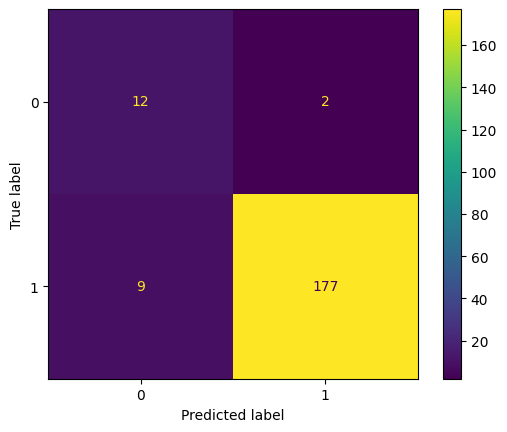

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [11]:
import joblib

joblib.dump(model, '/content/drive/MyDrive/lupus_model.pkl')

['/content/drive/MyDrive/lupus_model.pkl']

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.97


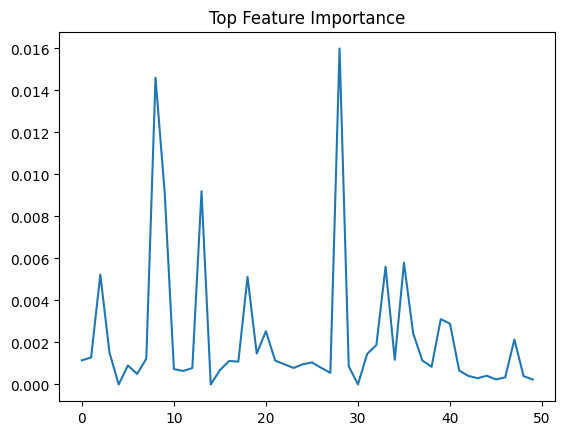

In [13]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
plt.plot(importances[:50])
plt.title("Top Feature Importance")
plt.show()

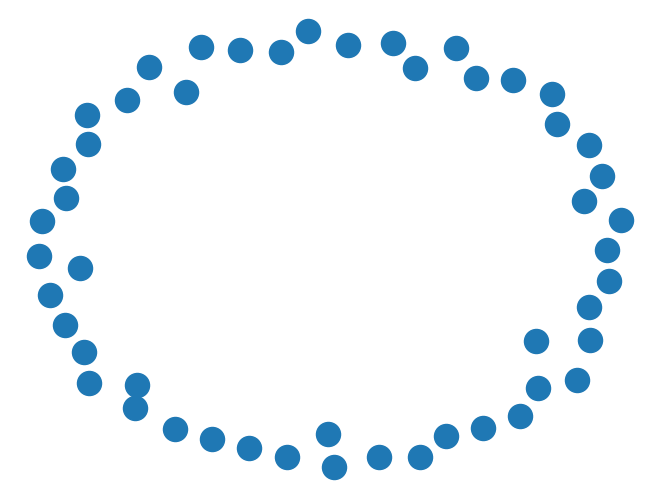

In [14]:
import networkx as nx

G = nx.Graph()

for i in range(50):
    G.add_node(f"Gene_{i}")

nx.draw(G, with_labels=False)

In [15]:
sample = X.iloc[10:11]
sample_selected = selector.transform(sample)

pred = model.predict(sample_selected)

print("Prediction:", "Lupus" if pred[0] == 1 else "Healthy")

Prediction: Lupus


In [16]:
# Get selected feature indices
selected_indices = selector.get_support(indices=True)

# Get feature names
selected_features = X.columns[selected_indices]

# Create reduced dataset
X_reduced = X[selected_features]

print(X_reduced.shape)

(996, 500)


In [17]:
corr_matrix = X_reduced.corr().abs()

In [18]:
import networkx as nx

G = nx.Graph()

# Use only first 30 genes (for clean graph)
cols = X_reduced.columns[:30]

for col in cols:
    G.add_node(col)

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        if corr_matrix.loc[cols[i], cols[j]] > 0.8:
            G.add_edge(cols[i], cols[j])

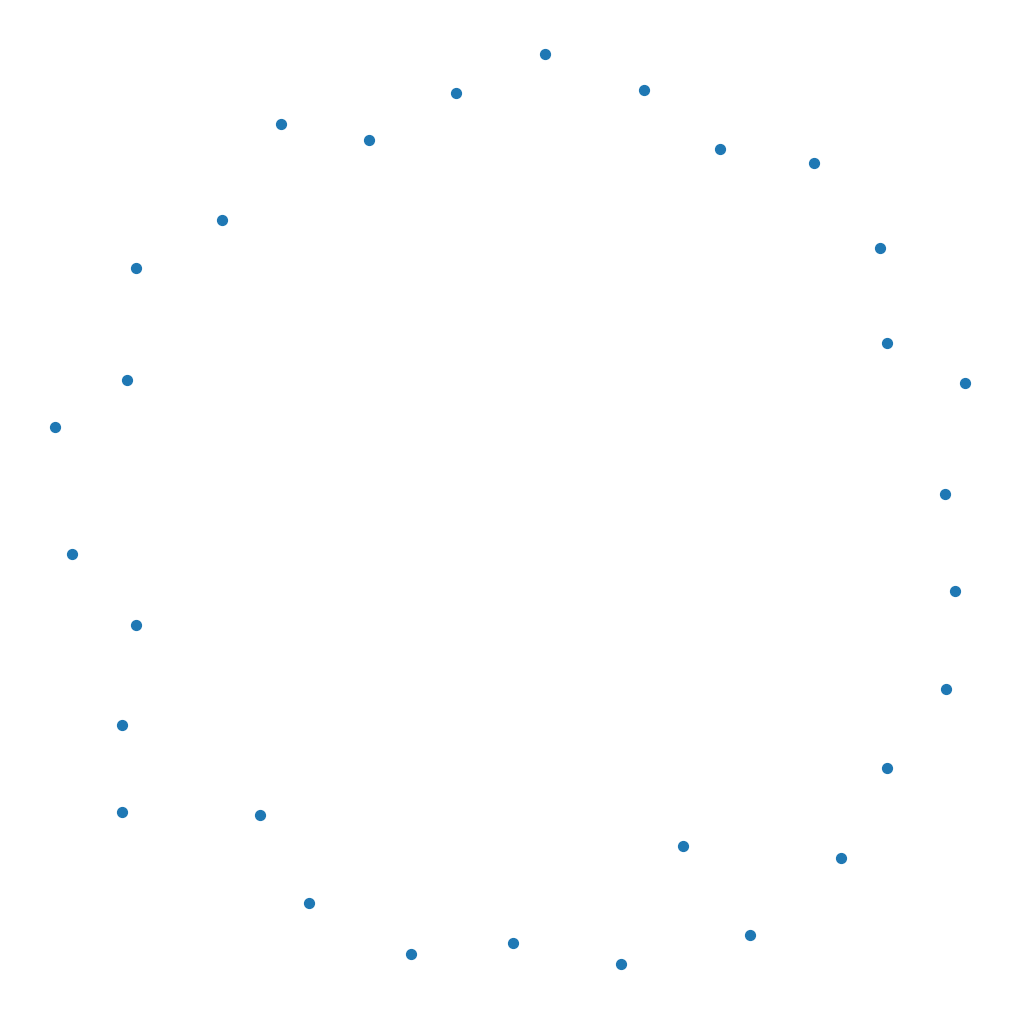

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
nx.draw(G, node_size=50, with_labels=False)
plt.show()